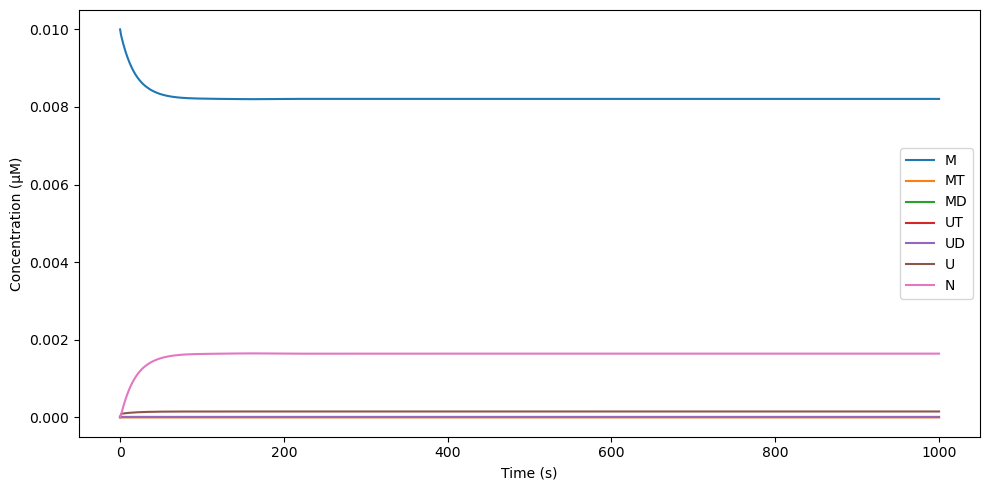

In [11]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def odes(t, y):
    M, MT, MD, UT, UD, U, N = y

    dM = -(k['kM_MT'] + k['kM_MD'] + k['kM_U']) * M \
         + k['kMT_M'] * MT + k['kMD_M'] * MD + k['kU_M'] * U

    dMT = -(k['kMT_M'] + k['kMT_MD'] + k['kMT_UT']) * MT \
          + k['kM_MT'] * M + k['kMD_MT'] * MD + k['kUT_MT'] * UT

    dMD = -(k['kMD_M'] + k['kMD_MT'] + k['kMD_UD']) * MD \
          + k['kM_MD'] * M + k['kMT_MD'] * MT + k['kUD_MD'] * UD

    dUT = -(k['kUT_U'] + k['kUT_UD'] + k['kUT_MT']) * UT \
          + k['kU_UT'] * U + k['kUD_UT'] * UD + k['kMT_UT'] * MT

    dUD = -(k['kUD_U'] + k['kUD_UT'] + k['kUD_MD']) * UD \
          + k['kU_UD'] * U + k['kUT_UD'] * UT + k['kMD_UD'] * MD

    dU = -(k['kU_UT'] + k['kU_UD'] + k['kU_M'] + k['kU_N']) * U \
         + k['kUT_U'] * UT + k['kUD_U'] * UD + k['kM_U'] * M + k['kN_U'] * N

    dN = -k['kN_U'] * N + k['kU_N'] * U

    return [dM, dMT, dMD, dUT, dUD, dU, dN]

#Given
DG_M_M70    = 2.5
DG_M70_U70  = 1.5
DG_U70_U    = 0
DG_M_U      = 4

tau= 60 

kATP_on_base = 1.28e+6   
kATP_off     = 2.31 
kADP_on_base = 1000 
kADP_off     = 2e-3 

kATP_plus = 1.3e+5
kATP_minus= 1.33e-4
kADP_plus = 2.67e+5
kADP_minus= 0.022

ksh = 1.8
k_h= 6e-4

Hsp70 = 10e-9 #10 micro M

ratio_ATP_ADP = 10

#Constraints

keff_ex_TD = (kADP_plus*kATP_minus)/(kADP_plus + kATP_plus*(ratio_ATP_ADP)) 
keff_ex_DT = (kADP_minus*kATP_plus*(ratio_ATP_ADP))/(kADP_plus + kATP_plus*(ratio_ATP_ADP)) 

kss = (ksh*keff_ex_DT)/keff_ex_TD 
k_s = (k_h/ksh)*kss

ratio_Hsp70_ATP_ADP = (keff_ex_DT+k_s)/(keff_ex_TD+k_h)

kATP_MU = kADP_MU = (1/tau) * np.exp(+DG_M70_U70)     

alpha = 1
gamma = 5

Hsp70_ATP = Hsp70/(1+ratio_Hsp70_ATP_ADP)
Hsp70_ADP = Hsp70 - Hsp70_ATP

k = {}

k['kM_MT'] = kATP_on_base * Hsp70_ATP * np.exp(-DG_M_M70)
k['kMT_M']  = kATP_off

k['kM_MD'] = kADP_on_base * Hsp70_ADP * np.exp(-DG_M_M70)
k['kMD_M']  = kADP_off

k['kMT_MD'] = keff_ex_TD + ksh
k['kMD_MT'] = keff_ex_DT + kss 

k['kMT_UT'] = kATP_MU * np.exp(-DG_M70_U70)
k['kUT_MT'] = k['kMT_UT'] * np.exp(+DG_M70_U70)

k['kMD_UD'] = kADP_MU * np.exp(-DG_M70_U70)
k['kUD_MD'] = k['kMD_UD'] * np.exp(+DG_M70_U70)

k['kUT_U']  = kATP_off * np.exp(-DG_U70_U)
k['kU_UT']  = kATP_on_base * Hsp70_ATP

k['kUD_U']  = kADP_off * np.exp(-DG_U70_U)
k['kU_UD']  = kADP_on_base * Hsp70_ADP

k['kUT_UD'] = keff_ex_TD + ksh
k['kUD_UT'] = keff_ex_DT + kss

k['kU_M']  = alpha
k['kM_U']  = k['kU_M'] * np.exp(-DG_M_U)

k['kU_N']   = k['kU_M']
k['kN_U']   = gamma * k['kM_U']

#unknown IC
y0 = [0.01, 0, 0, 0, 0, 0, 0]
t_eval = np.linspace(0, 1000, 800)

sol = solve_ivp(odes, (0, 1000), y0, method="BDF", t_eval=t_eval)



plt.figure(figsize=(10,5))
labels = ["M", "MT", "MD", "UT", "UD", "U", "N"]

for i, lab in enumerate(labels):
    plt.plot(sol.t, sol.y[i], label=lab)

plt.xlabel("Time (s)")
plt.ylabel("Concentration (µM)")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
#Steady state Ac=0

import numpy as np
from scipy.linalg import null_space

A = np.array([
    [-(k['kM_MT'] + k['kM_MD'] + k['kM_U']), k['kMT_M'], k['kMD_M'], 0, 0, k['kU_M'], 0],
    [k['kM_MT'], -(k['kMT_M'] + k['kMT_MD'] + k['kMT_UT']), k['kMD_MT'], k['kUT_MT'], 0, 0, 0],
    [k['kM_MD'], k['kMT_MD'], -(k['kMD_M'] + k['kMD_MT'] + k['kMD_UD']), 0, k['kUD_MD'], 0, 0],
    [0, k['kMT_UT'], 0, -(k['kUT_U'] + k['kUT_UD'] + k['kUT_MT']), k['kUD_UT'], k['kU_UT'], 0],
    [0, 0, k['kMD_UD'], k['kUT_UD'], -(k['kUD_U'] + k['kUD_UT'] + k['kUD_MD']), k['kU_UD'], 0],
    [k['kM_U'], 0, 0, k['kUT_U'], k['kUD_U'], -(k['kU_UT'] + k['kU_UD'] + k['kU_M'] + k['kU_N']), k['kN_U']],
    [0, 0, 0, 0, 0, k['kU_N'], -k['kN_U']]
], dtype=float)

ns = null_space(A)
print(ns)

#normalisation, sum=1
ns/=ns.sum()

labels = ["M", "MT", "MD", "UT", "UD", "U", "N"]
for lab, val in zip(labels, steady_state):
    print(f"{lab} = {val:.6f}")


[[9.80422566e-01]
 [9.00966139e-07]
 [1.67311954e-09]
 [2.01032719e-07]
 [3.73323431e-10]
 [1.79570657e-02]
 [1.96084513e-01]]
M = 0.000887
MT = 0.815177
MD = 0.001514
UT = 0.181891
UD = 0.000338
U = 0.000016
N = 0.000177
